In [1]:
import re
import math
import random
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download("punkt")
from nltk.tokenize import PunktSentenceTokenizer, TreebankWordTokenizer

import tensorflow as tf
from tensorflow.keras import layers, models


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ulan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
c:\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
with open("Pride_and_prejudice.txt", "r", encoding="utf8") as f:
    text = f.read().lower()

# Remove Gutenberg header/footer
start = text.find("it is a truth universally acknowledged")
end = text.find("end of the project gutenberg ebook")
text = text[start:end]


In [3]:
sent_tokenizer = PunktSentenceTokenizer()
word_tokenizer = TreebankWordTokenizer()

sentences = sent_tokenizer.tokenize(text)

tokenized = []
for s in sentences:
    tokens = word_tokenizer.tokenize(s)
    tokens = [re.sub(r"[^a-z]", "", w) for w in tokens]
    tokens = [w for w in tokens if w]
    tokenized.append(["<bos>"] + tokens + ["<eos>"])


In [4]:
all_tokens = [w for s in tokenized for w in s]
counts = Counter(all_tokens)

min_freq = 2
vocab = {w for w, c in counts.items() if c >= min_freq}
vocab |= {"<unk>", "<bos>", "<eos>"}

def replace_oov(sent):
    return [w if w in vocab else "<unk>" for w in sent]

tokenized = [replace_oov(s) for s in tokenized]

print("Vocabulary size:", len(vocab))


Vocabulary size: 3948


In [5]:
random.seed(42)
random.shuffle(tokenized)

n = len(tokenized)
train = tokenized[:int(0.8*n)]
val   = tokenized[int(0.8*n):int(0.9*n)]
test  = tokenized[int(0.9*n):]


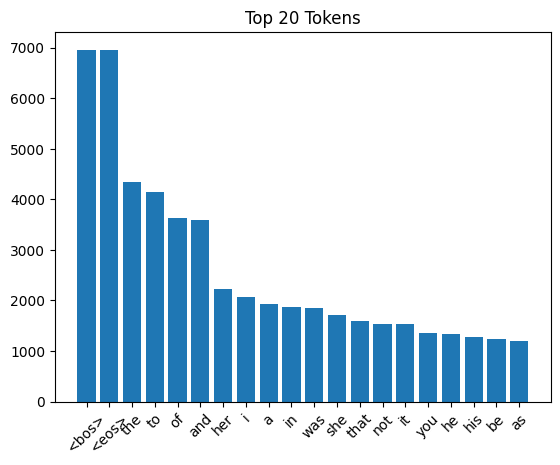

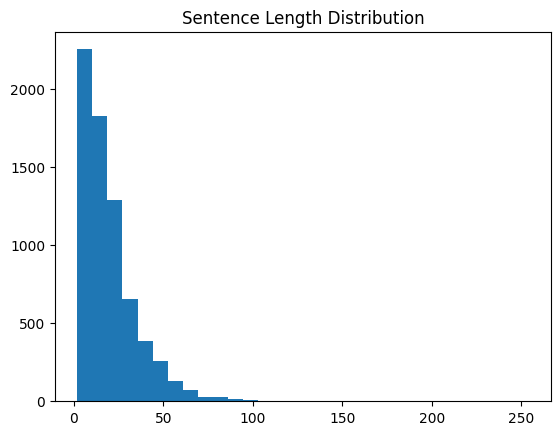

In [6]:
# Top 20 tokens
words, freqs = zip(*counts.most_common(20))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("Top 20 Tokens")
plt.show()

# Sentence lengths
lengths = [len(s) for s in tokenized]
plt.hist(lengths, bins=30)
plt.title("Sentence Length Distribution")
plt.show()


In [7]:
trigram_counts = defaultdict(int)
bigram_counts = defaultdict(int)

for s in train:
    for i in range(len(s)-2):
        trigram_counts[(s[i], s[i+1], s[i+2])] += 1
        bigram_counts[(s[i], s[i+1])] += 1


In [8]:
V = len(vocab)

def trigram_prob(w1, w2, w3):
    return (trigram_counts[(w1,w2,w3)] + 1) / (bigram_counts[(w1,w2)] + V)

def perplexity(data):
    log_prob = 0
    N = 0
    for s in data:
        for i in range(len(s)-2):
            log_prob += math.log(trigram_prob(s[i], s[i+1], s[i+2]))
            N += 1
    return math.exp(-log_prob / N)

trigram_ppl = perplexity(test)
print("Trigram Test Perplexity:", trigram_ppl)


Trigram Test Perplexity: 2715.009739190652


In [9]:
def generate_trigram(n=30):
    w1, w2 = "<bos>", "<bos>"
    out = [w1, w2]

    for _ in range(n):
        candidates = []
        probs = []
        for w in vocab:
            candidates.append(w)
            probs.append(trigram_prob(w1, w2, w))
        w3 = random.choices(candidates, probs)[0]
        out.append(w3)
        w1, w2 = w2, w3

    return " ".join(out)

print(generate_trigram())


<bos> <bos> shortly detached union convince shake adieu marry maintained hat lest grow envelope excused failed vulgar consoling advance induced insensibility allowance contrived besides done wedding persist comfortable beauties asking connection behind


In [10]:
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

def encode(data):
    return [[word2idx[w] for w in s] for s in data]

train_enc = encode(train)
val_enc   = encode(val)
test_enc  = encode(test)

SEQ_LEN = 20

def make_sequences(data):
    X, y = [], []
    for s in data:
        for i in range(len(s)-SEQ_LEN):
            X.append(s[i:i+SEQ_LEN])
            y.append(s[i+SEQ_LEN])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_enc)
X_val, y_val     = make_sequences(val_enc)
X_test, y_test   = make_sequences(test_enc)


In [ ]:
class TiedLSTMLM(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = layers.Embedding(vocab_size, embed_dim)
        self.lstm = layers.LSTM(hidden_dim)
        self.hidden_to_embed = layers.Dense(embed_dim)

    def call(self, x):
        emb = self.embedding(x)                 # (B, T, E)
        h = self.lstm(emb)                      # (B, H)
        h = self.hidden_to_embed(h)             # (B, E)

        # weight tying я использовал одну и ту же матрицу для входа и выхода из за ошибок ибо оно уменьшает число параметров и улучшает обобщение
        logits = tf.matmul(h, self.embedding.embeddings, transpose_b=True)
        return logits

model_lstm = TiedLSTMLM(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=256
)

model_lstm.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)


Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 6.1124 - val_loss: 5.8122
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 5.6327 - val_loss: 5.6627
Epoch 3/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 5.4292 - val_loss: 5.5903
Epoch 4/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 5.2352 - val_loss: 5.4669
Epoch 5/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 5.0549 - val_loss: 5.4639


In [13]:
inputs = layers.Input(shape=(SEQ_LEN,))
x = layers.Embedding(vocab_size, embed_dim)(inputs)
x = layers.Conv1D(256, 3, activation="relu")(x)
x = layers.GlobalMaxPooling1D()(x)
outputs = layers.Dense(vocab_size)(x)

model_cnn = models.Model(inputs, outputs)
model_cnn.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)


Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 6.2759 - val_loss: 6.0097
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5.9505 - val_loss: 6.0001
Epoch 3/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 5.8399 - val_loss: 6.0131
Epoch 4/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5.6439 - val_loss: 6.0877
Epoch 5/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5.3557 - val_loss: 6.2511


In [14]:
def neural_perplexity(model, X, y):
    loss = model.evaluate(X, y, verbose=0)
    return math.exp(loss)

print("Trigram:", trigram_ppl)
print("LSTM:", neural_perplexity(model_lstm, X_test, y_test))
print("CNN:", neural_perplexity(model_cnn, X_test, y_test))


Trigram: 2715.009739190652
LSTM: 234.79629298614964
CNN: 528.6018692980806


In [17]:
sample = X_test[0:1]

with tf.GradientTape() as tape:
    logits = model_lstm(sample)
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=y_test[0:1],
        logits=logits
    )

# Gradient w.r.t. embedding matrix
grads = tape.gradient(loss, model_lstm.embedding.weights[0])

# Importance = L2 norm per token embedding
importance = tf.norm(grads, axis=1).numpy()

top_ids = np.argsort(importance)[-10:]
top_words = [idx2word[i] for i in top_ids]

print("Most influential tokens:", top_words)


Most influential tokens: ['father', 'supposed', 'thing', 'sister', 'marriage', 'and', '<unk>', 'planning', 'his', 'happiness']
